In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading dataset
print("Loading dataset...")
df = pd.read_csv('raw_metadata.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Loading dataset...
Dataset shape: (125, 3)


,video_id,title,publish_date
0,2KaAHD2TOos,Is dust really people?,2026-02-13
1,iT2n41ZFDc0,The Intelligence Test Where Ants Beat Humans,2026-02-05
2,UI8pp2j2fZ8,What time is it on Voyager 1? 🤔,2026-01-30
3,rTvTsvT7y7s,What&#39;s REALLY killing all the birds?,2026-01-23
4,AxE13l_rXOI,How much does Will Smith know about nature?,2026-01-18


In [3]:
# Dataset structure
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

# Duplicate & Missing Value Check
print(f"\nDuplicate video_id: {df['video_id'].duplicated().sum()}")
if df['video_id'].duplicated().sum() > 0:
    df = df.drop_duplicates(subset=['video_id'], keep='first')
    print("Removed duplicates.")

print("\nMissing values:")
print(df[['video_id', 'title', 'publish_date']].isnull().sum())

Column names: ['video_id', 'title', 'publish_date']

Data types:
video_id        str
title           str
publish_date    str
dtype: object

Duplicate video_id: 0

Missing values:
video_id        0
title           0
publish_date    0
dtype: int64


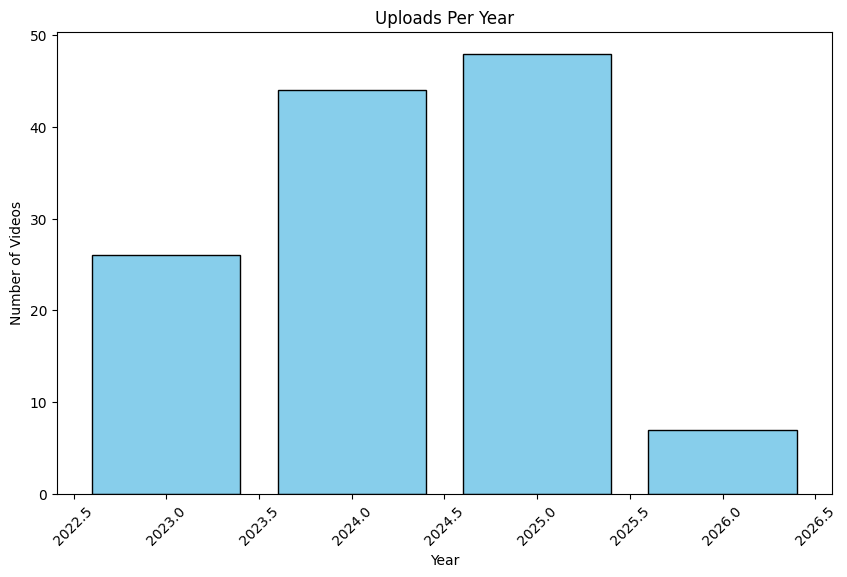

In [4]:
# Date conversion
df['publish_date'] = pd.to_datetime(df['publish_date'], errors='coerce')
df['year'] = df['publish_date'].dt.year
df['month'] = df['publish_date'].dt.month

# Visualizing Upload Frequency
plt.figure(figsize=(10,6))
year_counts = df['year'].value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
plt.title('Uploads Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45)
plt.show()

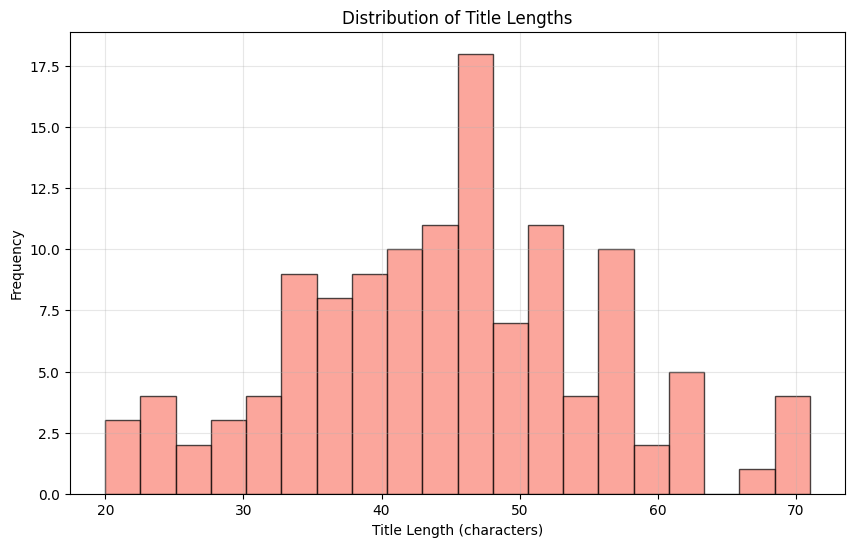

Average title length: 44.7 chars


In [5]:
# Title analysis
df['title_length'] = df['title'].str.len()

plt.figure(figsize=(10,6))
plt.hist(df['title_length'], bins=20, edgecolor='black', color='salmon', alpha=0.7)
plt.title('Distribution of Title Lengths')
plt.xlabel('Title Length (characters)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Average title length: {round(df['title_length'].mean(), 1)} chars")

In [6]:
# Title cleaning (spaces + newlines)
df['title'] = df['title'].str.strip()
df['title'] = df['title'].str.replace('\n', ' ', regex=False)
df['title'] = df['title'].str.replace(r'\s+', ' ', regex=True)

# Saving cleaned dataset
cleaned_df = df[['video_id', 'title', 'publish_date', 'year', 'month', 'title_length']].copy()
cleaned_df.to_csv('cleaned_metadata.csv', index=False)
print("Saved cleaned_metadata.csv successfully!")


Saved cleaned_metadata.csv successfully!
